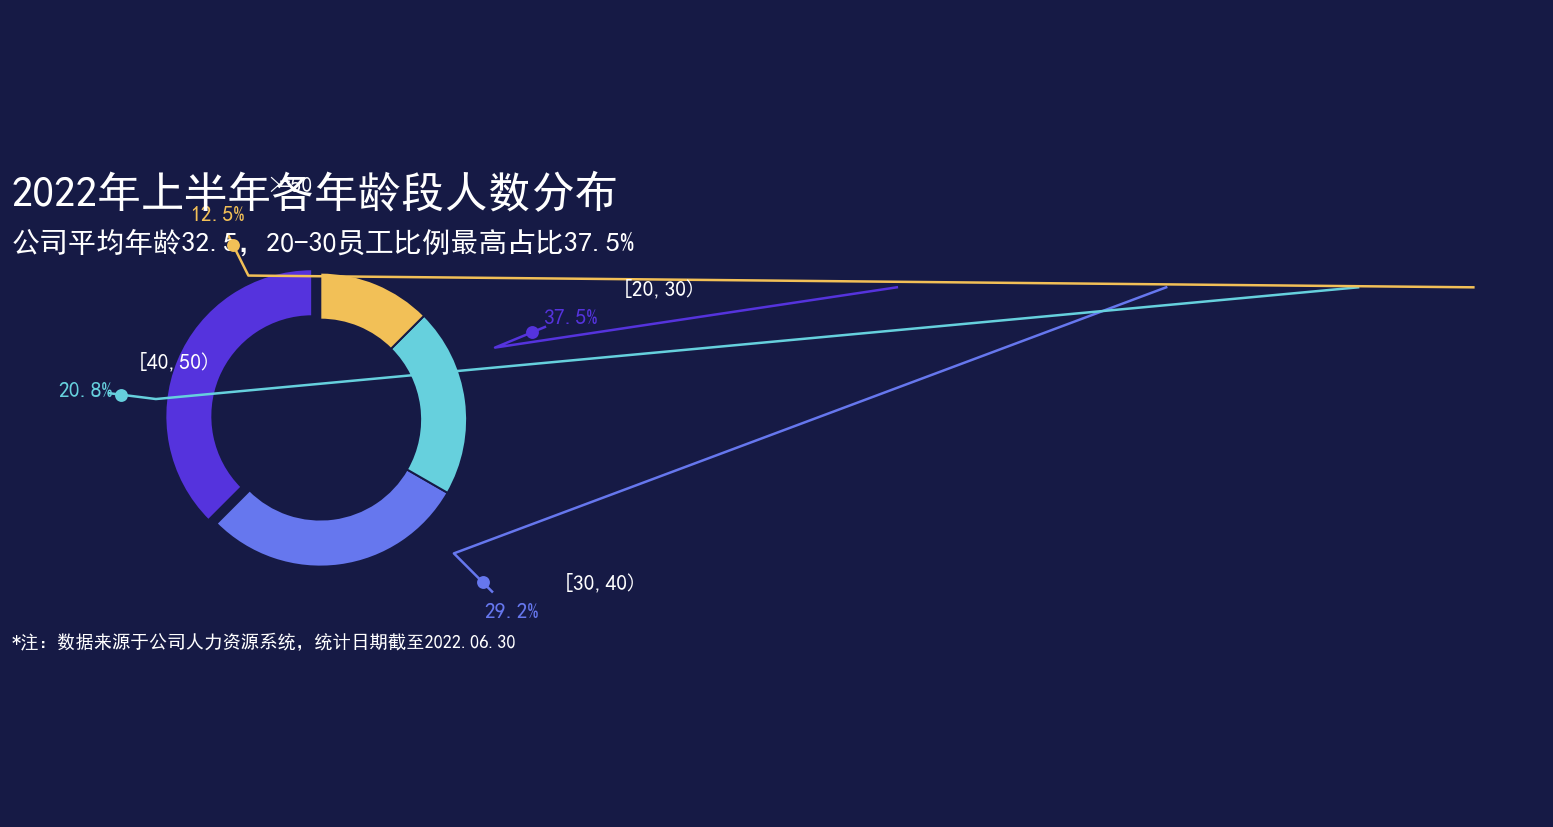

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 中文兼容配置 消除字体警告 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 1. 准备年龄段分布数据 ----------------------
age_groups = ["[20,30)", "[30,40)", "[40,50)", ">=50"]
percentages = [37.5, 29.2, 20.8, 12.5]
colors = ['#5533dd', '#6677ee', '#66d0dd', '#f2c057']

# ---------------------- 2. 画布与背景风格设置 ----------------------
plt.figure(figsize=(13, 7), dpi=120)
plt.gcf().set_facecolor('#161a45')
ax = plt.gca()
ax.set_facecolor('#161a45')

# ---------------------- 3. 绘制分层空心环形饼图 ----------------------
wedges, _ = ax.pie(
    percentages,
    colors=colors,
    wedgeprops=dict(width=0.32, edgecolor='#161a45', linewidth=1.2),
    startangle=90,
    explode=[0.06, 0, 0, 0]  # 让占比最高的20-30段轻微突出
)

# ---------------------- 4. 绘制引线+圆点标注 ----------------------
annot_pos = [
    (1.7, 0.7, '#5533dd'),
    (1.3, -1.3, '#6677ee'),
    (-1.6, 0.2, '#66d0dd'),
    (-0.7, 1.4, '#f2c057')
]
for idx, (wedge, (tx, ty, c)) in enumerate(zip(wedges, annot_pos)):
    # 圆点标记
    ax.scatter(tx*0.85, ty*0.85, color=c, s=45, zorder=5)
    # 折线引线
    ax.plot([wedge.theta2/180*np.pi, tx*0.7, tx*0.9], 
            [wedge.r*0.9, ty*0.7, ty*0.9], color=c, linewidth=1.5)
    # 百分比文字标注
    ax.text(tx, ty, f'{percentages[idx]}%', ha='center', va='center', color=c, fontsize=13)
    # 年龄段标签
    ax.text(tx+0.35, ty+0.2, age_groups[idx], ha='left', va='center', color='white', fontsize=13)

# ---------------------- 5. 标题与底部注释 ----------------------
plt.text(-2.1, 1.45, '2022年上半年各年龄段人数分布', color='white', fontsize=26, fontweight='bold')
plt.text(-2.1, 1.15, '公司平均年龄32.5，20-30员工比例最高占比37.5%', color='white', fontsize=17)
plt.text(-2.1, -1.55, '*注：数据来源于公司人力资源系统，统计日期截至2022.06.30', color='white', fontsize=11)

# 保证饼图为正圆形
ax.axis('equal')
plt.tight_layout()
plt.show()


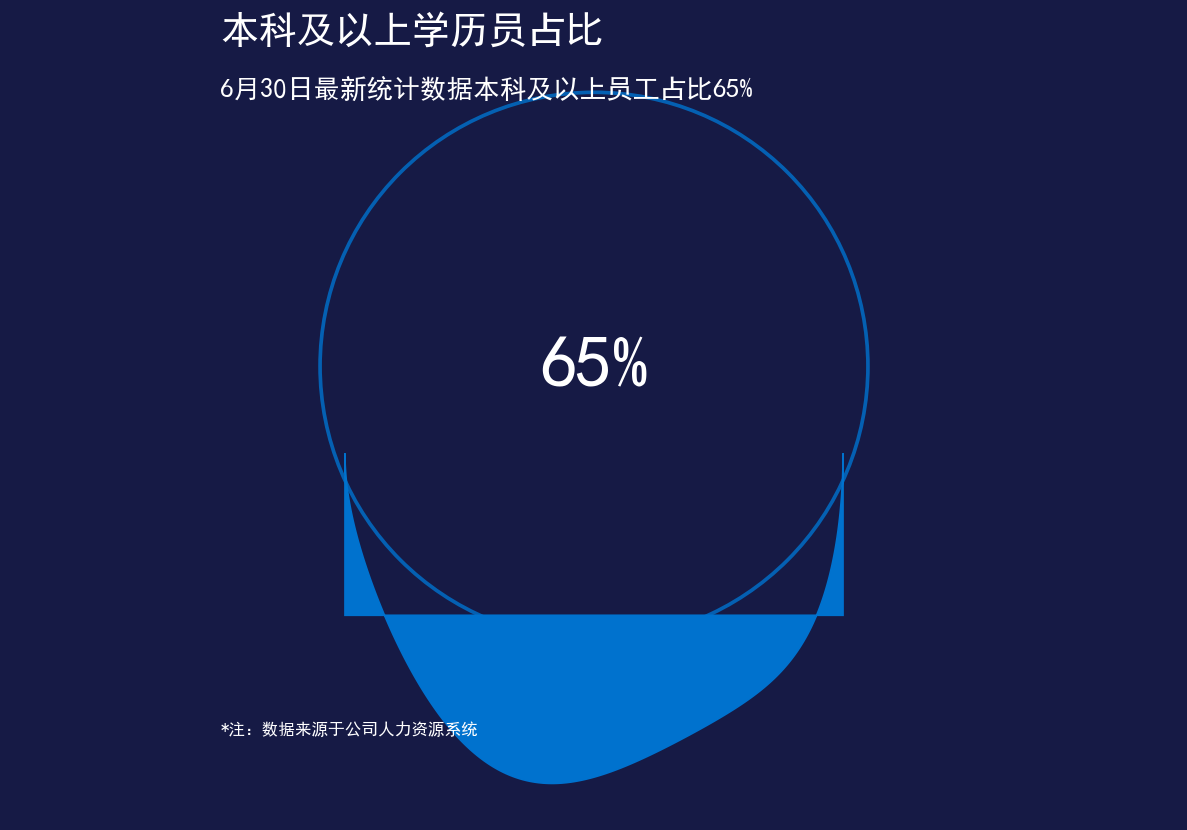

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 中文兼容配置 消除字体警告 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 1. 准备占比数据 ----------------------
complete_rate = 0.65

# ---------------------- 2. 画布与背景风格设置 ----------------------
plt.figure(figsize=(10, 7), dpi=120)
plt.gcf().set_facecolor('#161a45')
ax = plt.gca()
ax.set_facecolor('#161a45')

# ---------------------- 3. 绘制带波浪水纹的填充圆形 ----------------------
theta = np.linspace(np.pi, 2*np.pi, 300)
# 基础半圆填充
x_base = np.cos(theta)
y_base = np.sin(theta) * complete_rate * 2 - (1 - complete_rate)
# 添加顶部波浪效果
wave = 0.07 * np.sin(theta * 4)
y_wave = y_base + wave
# 闭合填充区域
x_fill = np.concatenate([x_base, [x_base[-1], x_base[0]]])
y_fill = np.concatenate([y_wave, [-1, -1]])
ax.fill(x_fill, y_fill, color='#0072ce', zorder=2)

# 绘制外层蓝色细圆环
circle_border = plt.Circle((0, 0), 1.1, color='#0072ce', fill=False, linewidth=2.2, alpha=0.8, zorder=3)
ax.add_patch(circle_border)

# ---------------------- 4. 中心百分比文字标注 ----------------------
ax.text(0, 0, f'{int(complete_rate*100)}%', ha='center', va='center', 
        color='white', fontsize=44, fontweight='medium')

# ---------------------- 5. 坐标轴隐藏 ----------------------
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.6, 1.6)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# ---------------------- 6. 标题与底部注释 ----------------------
plt.text(-1.5, 1.3, '本科及以上学历员占比', color='white', fontsize=23, fontweight='bold')
plt.text(-1.5, 1.08, '6月30日最新统计数据本科及以上员工占比65%', color='white', fontsize=16)
plt.text(-1.5, -1.48, '*注：数据来源于公司人力资源系统', color='white', fontsize=10)

# 保证图形为正圆形
ax.axis('equal')
plt.tight_layout()
plt.show()


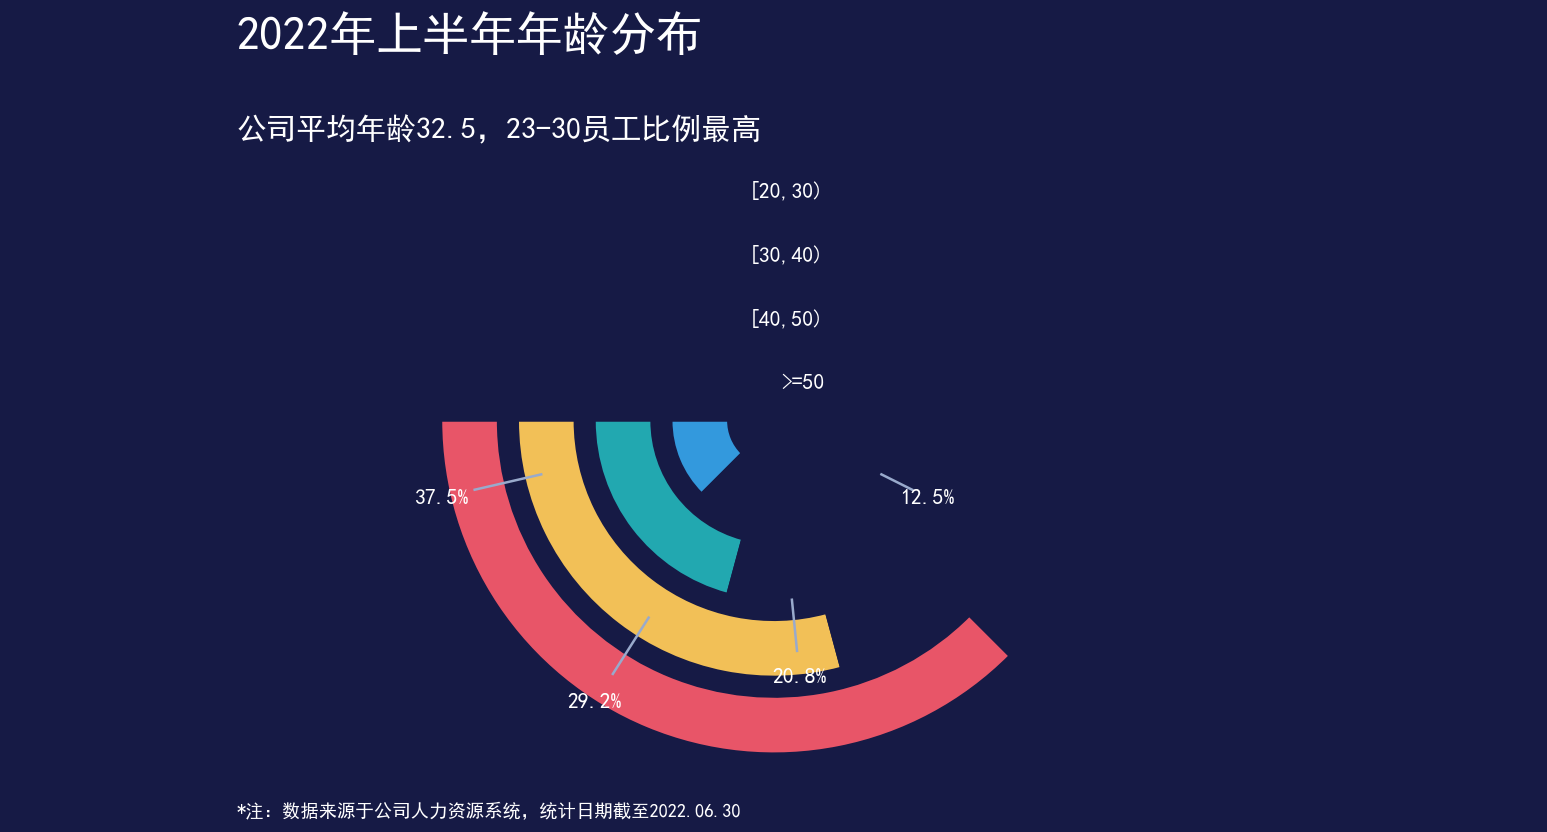

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 中文兼容配置 消除字体警告 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 1. 准备各层年龄分布数据 ----------------------
# 从外层到内层的占比和对应配置
layer_data = [
    {"percents": [37.5, 62.5], "colors": ["#e85568", "#161a45"], "width": 0.22, "radius": 1.3},
    {"percents": [29.2, 70.8], "colors": ["#f2c057", "#161a45"], "width": 0.22, "radius": 1.0},
    {"percents": [20.8, 79.2], "colors": ["#22a8b0", "#161a45"], "width": 0.22, "radius": 0.7},
    {"percents": [12.5, 87.5], "colors": ["#3399dd", "#161a45"], "width": 0.22, "radius": 0.4}
]
labels = ["[20,30)", "[30,40)", "[40,50)", ">=50"]
annot_percents = ["37.5%", "29.2%", "20.8%", "12.5%"]

# ---------------------- 2. 画布与背景风格设置 ----------------------
plt.figure(figsize=(13, 7), dpi=120)
plt.gcf().set_facecolor('#161a45')
ax = plt.gca()
ax.set_facecolor('#161a45')

# ---------------------- 3. 逐层绘制嵌套环形 ----------------------
for layer in layer_data:
    ax.pie(
        layer["percents"],
        colors=layer["colors"],
        radius=layer["radius"],
        wedgeprops=dict(width=layer["width"], edgecolor='#161a45', linewidth=1),
        startangle=180
    )

# ---------------------- 4. 标注百分比 + 引线 ----------------------
annot_pos = [(-1.3, -0.3), (-0.7, -1.1), (0.1, -1.0), (0.6, -0.3)]
for idx, (pos, p_text) in enumerate(zip(annot_pos, annot_percents)):
    ax.text(pos[0], pos[1], p_text, ha='center', va='center', color='white', fontsize=13)
    # 绘制浅灰色引线
    ax.plot([pos[0]*0.7, pos[0]*0.9], [pos[1]*0.7, pos[1]*0.9], color='#99aacc', linewidth=1.5)

# 标注左侧年龄段标签
label_pos = [(0.2, 0.9), (0.2, 0.65), (0.2, 0.4), (0.2, 0.15)]
for idx, (pos, lab) in enumerate(zip(label_pos, labels)):
    ax.text(pos[0], pos[1], lab, ha='right', va='center', color='white', fontsize=13)

# ---------------------- 5. 标题与底部注释 ----------------------
plt.text(-2.1, 1.45, '2022年上半年年龄分布', color='white', fontsize=28, fontweight='bold')
plt.text(-2.1, 1.1, '公司平均年龄32.5，23-30员工比例最高', color='white', fontsize=18)
plt.text(-2.1, -1.55, '*注：数据来源于公司人力资源系统，统计日期截至2022.06.30', color='white', fontsize=11)

# 保证图形为正圆形
ax.axis('equal')
plt.tight_layout()
plt.show()


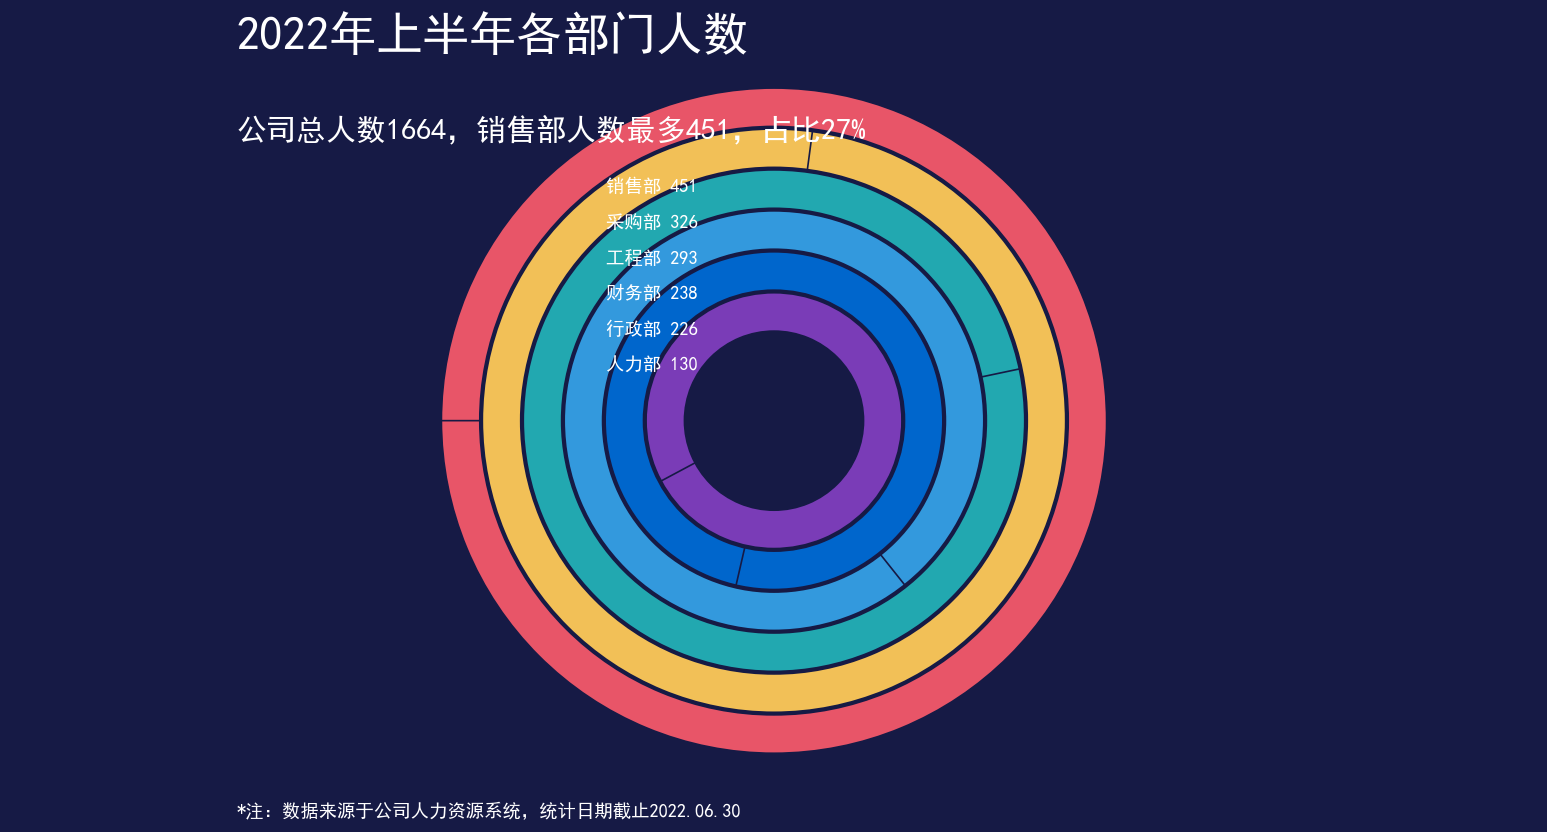

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 中文兼容配置 消除字体警告 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 1. 准备各部门人数数据 ----------------------
departments = ["销售部", "采购部", "工程部", "财务部", "行政部", "人力部"]
staff_counts = [451, 326, 293, 238, 226, 130]
colors = ['#e85568', '#f2c057', '#22a8b0', '#3399dd', '#0066cc', '#7a3cb7']
total_staff = sum(staff_counts)

# ---------------------- 2. 画布与背景风格设置 ----------------------
plt.figure(figsize=(13, 7), dpi=120)
plt.gcf().set_facecolor('#161a45')
ax = plt.gca()
ax.set_facecolor('#161a45')

# ---------------------- 3. 逐层绘制嵌套弧形 ----------------------
start_angle = 180
for idx, (count, color) in enumerate(zip(staff_counts, colors)):
    # 计算当前弧形的角度跨度
    angle_span = (count / total_staff) * 360
    # 从外层到内层依次绘制
    ax.pie(
        [100, 0],
        colors=[color, '#161a45'],
        radius=1.3 - idx*0.16,
        wedgeprops=dict(width=0.15, edgecolor='#161a45', linewidth=1),
        startangle=start_angle
    )
    start_angle -= angle_span

# ---------------------- 4. 标注部门名称和人数 ----------------------
label_pos = [(-0.3, 0.92), (-0.3, 0.78), (-0.3, 0.64), (-0.3, 0.5), (-0.3, 0.36), (-0.3, 0.22)]
for idx, (pos, dep, cnt) in enumerate(zip(label_pos, departments, staff_counts)):
    ax.text(pos[0], pos[1], f'{dep} {cnt}', ha='right', va='center', color='white', fontsize=11)

# ---------------------- 5. 标题与底部注释 ----------------------
plt.text(-2.1, 1.45, '2022年上半年各部门人数', color='white', fontsize=28, fontweight='bold')
plt.text(-2.1, 1.1, f'公司总人数{total_staff}，销售部人数最多451，占比27%', color='white', fontsize=18)
plt.text(-2.1, -1.55, '*注：数据来源于公司人力资源系统，统计日期截止2022.06.30', color='white', fontsize=11)

# 保证图形为正圆形
ax.axis('equal')
plt.tight_layout()
plt.show()


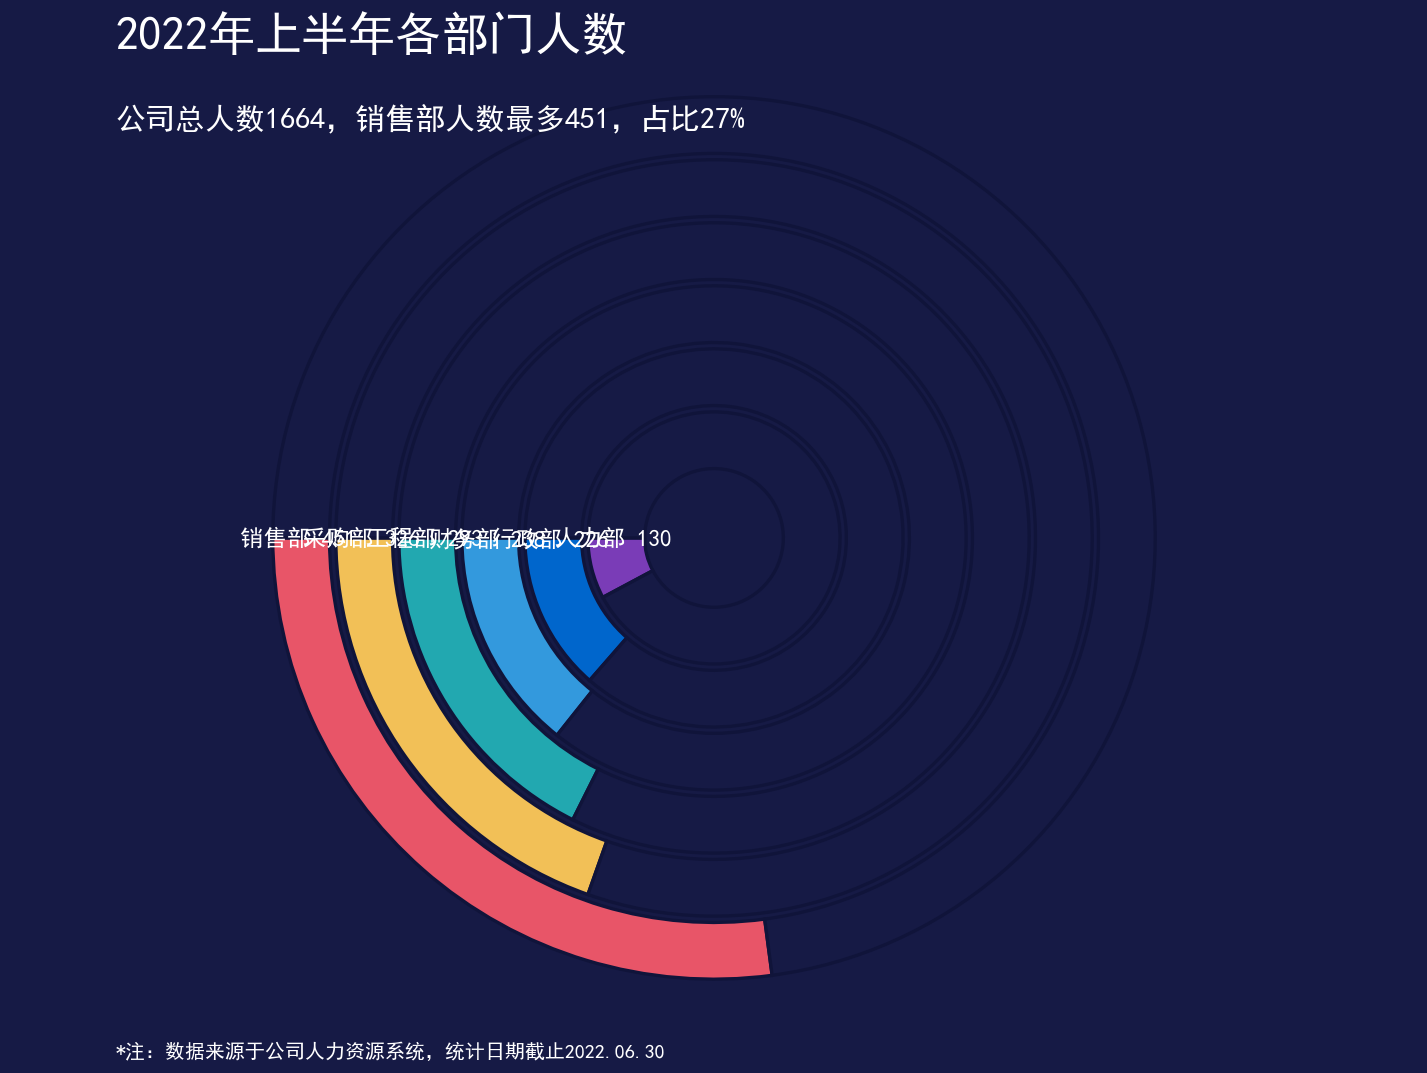

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 中文兼容配置 消除字体警告 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 1. 准备各部门人数数据 ----------------------
departments = ["销售部", "采购部", "工程部", "财务部", "行政部", "人力部"]
staff_counts = [451, 326, 293, 238, 226, 130]
colors = ['#e85568', '#f2c057', '#22a8b0', '#3399dd', '#0066cc', '#7a3cb7']
total_staff = sum(staff_counts)

# ---------------------- 2. 画布与背景风格设置 ----------------------
plt.figure(figsize=(12, 9), dpi=120)
plt.gcf().set_facecolor('#161a45')
ax = plt.gca()
ax.set_facecolor('#161a45')

# ---------------------- 3. 逐层绘制全周嵌套环形 ----------------------
for idx, (count, color) in enumerate(zip(staff_counts, colors)):
    # 从最外层到最内层依次绘制完整环形
    ax.pie(
        [count, total_staff - count],
        colors=[color, '#161a45'],
        radius=1.4 - idx*0.2,
        wedgeprops=dict(width=0.18, edgecolor='#10143a', linewidth=2),
        startangle=180
    )

# ---------------------- 4. 嵌入部门名称+人数标签 ----------------------
label_radius = [1.32, 1.12, 0.92, 0.72, 0.52, 0.32]
for idx, (r, dep, cnt) in enumerate(zip(label_radius, departments, staff_counts)):
    ax.text(-r, 0, f'{dep} {cnt}', ha='center', va='center', color='white', fontsize=14)

# ---------------------- 5. 标题与底部注释 ----------------------
plt.text(-1.9, 1.55, '2022年上半年各部门人数', color='white', fontsize=28, fontweight='bold')
plt.text(-1.9, 1.3, f'公司总人数{total_staff}，销售部人数最多451，占比27%', color='white', fontsize=18)
plt.text(-1.9, -1.65, '*注：数据来源于公司人力资源系统，统计日期截止2022.06.30', color='white', fontsize=12)

# 保证图形为正圆形
ax.axis('equal')
plt.tight_layout()
plt.show()


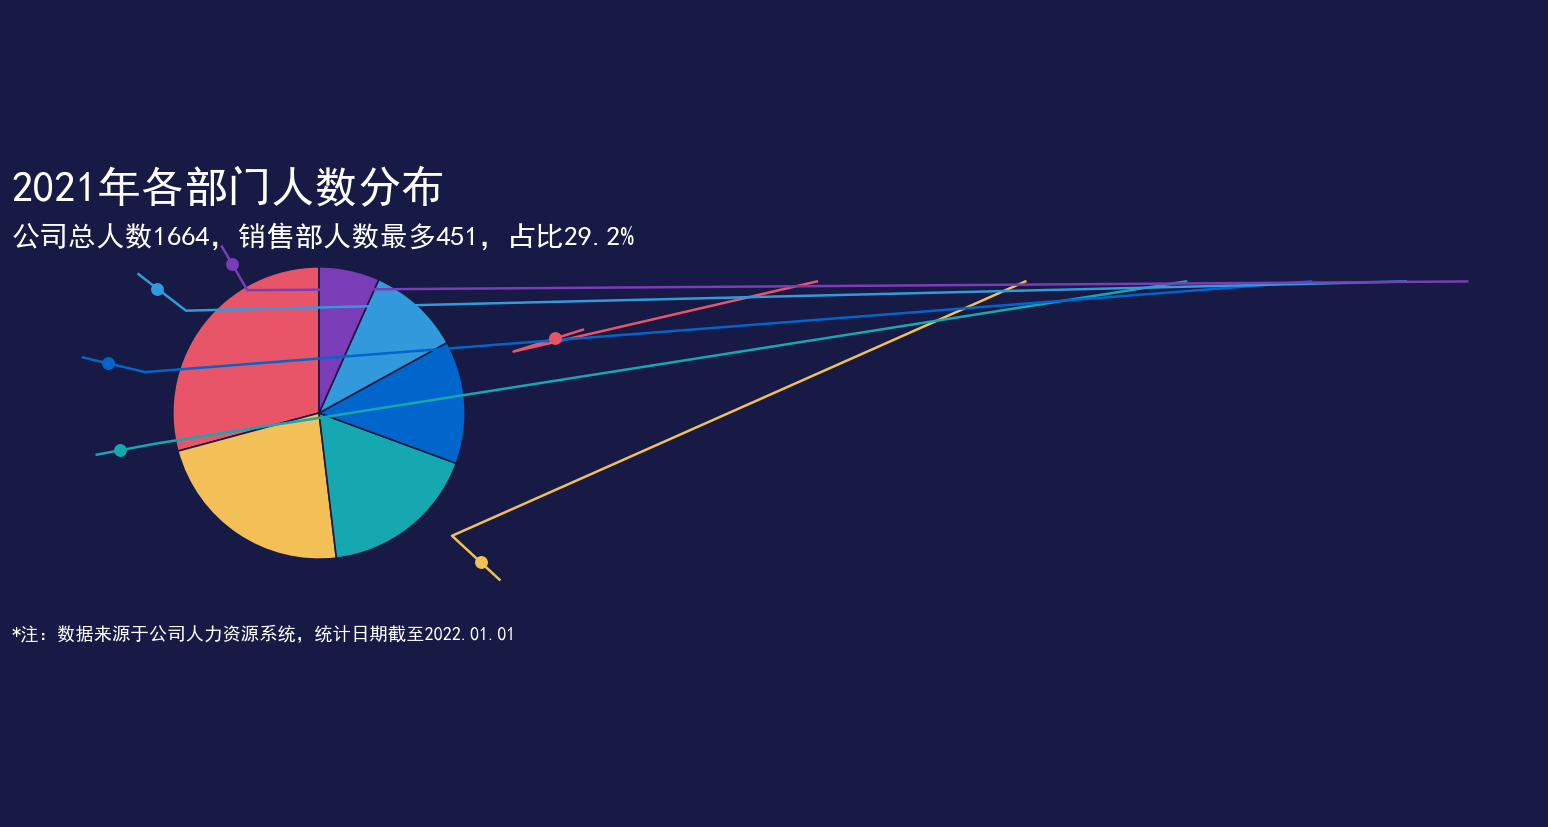

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 中文兼容配置 消除字体警告 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 1. 准备部门人数占比数据 ----------------------
departments = ["销售部", "采购部", "工程部", "财务部", "行政部", "人力部"]
percents = [29.2, 22.7, 17.5, 13.6, 10.3, 6.7]
colors = ['#e85568', '#f2c057', '#16a8b0', '#0066cc', '#3399dd', '#7a3cb7']

# ---------------------- 2. 画布与背景风格设置 ----------------------
plt.figure(figsize=(13, 7), dpi=120)
plt.gcf().set_facecolor('#161a45')
ax = plt.gca()
ax.set_facecolor('#161a45')

# ---------------------- 3. 绘制基础彩色饼图 ----------------------
wedges, _ = ax.pie(
    percents,
    colors=colors,
    wedgeprops=dict(edgecolor='#161a45', linewidth=1),
    startangle=90
)

# ---------------------- 4. 绘制折线圆点引线标注 ----------------------
annot_pos = [
    (1.9, 0.6, '#e85568'),
    (1.3, -1.2, '#f2c057'),
    (-1.6, -0.3, '#16a8b0'),
    (-1.7, 0.4, '#0066cc'),
    (-1.3, 1.0, '#3399dd'),
    (-0.7, 1.2, '#7a3cb7')
]
for idx, (wedge, (tx, ty, c)) in enumerate(zip(wedges, annot_pos)):
    # 圆点标记
    ax.scatter(tx*0.85, ty*0.85, color=c, s=45, zorder=5)
    # 折线引线
    ax.plot([wedge.theta2/180*np.pi, tx*0.7, tx*0.95], 
            [wedge.r*0.9, ty*0.7, ty*0.95], color=c, linewidth=1.5)

# ---------------------- 5. 标题与底部注释 ----------------------
plt.text(-2.1, 1.45, '2021年各部门人数分布', color='white', fontsize=26, fontweight='bold')
plt.text(-2.1, 1.15, '公司总人数1664，销售部人数最多451，占比29.2%', color='white', fontsize=17)
plt.text(-2.1, -1.55, '*注：数据来源于公司人力资源系统，统计日期截至2022.01.01', color='white', fontsize=11)

# 保证饼图为正圆形
ax.axis('equal')
plt.tight_layout()
plt.show()


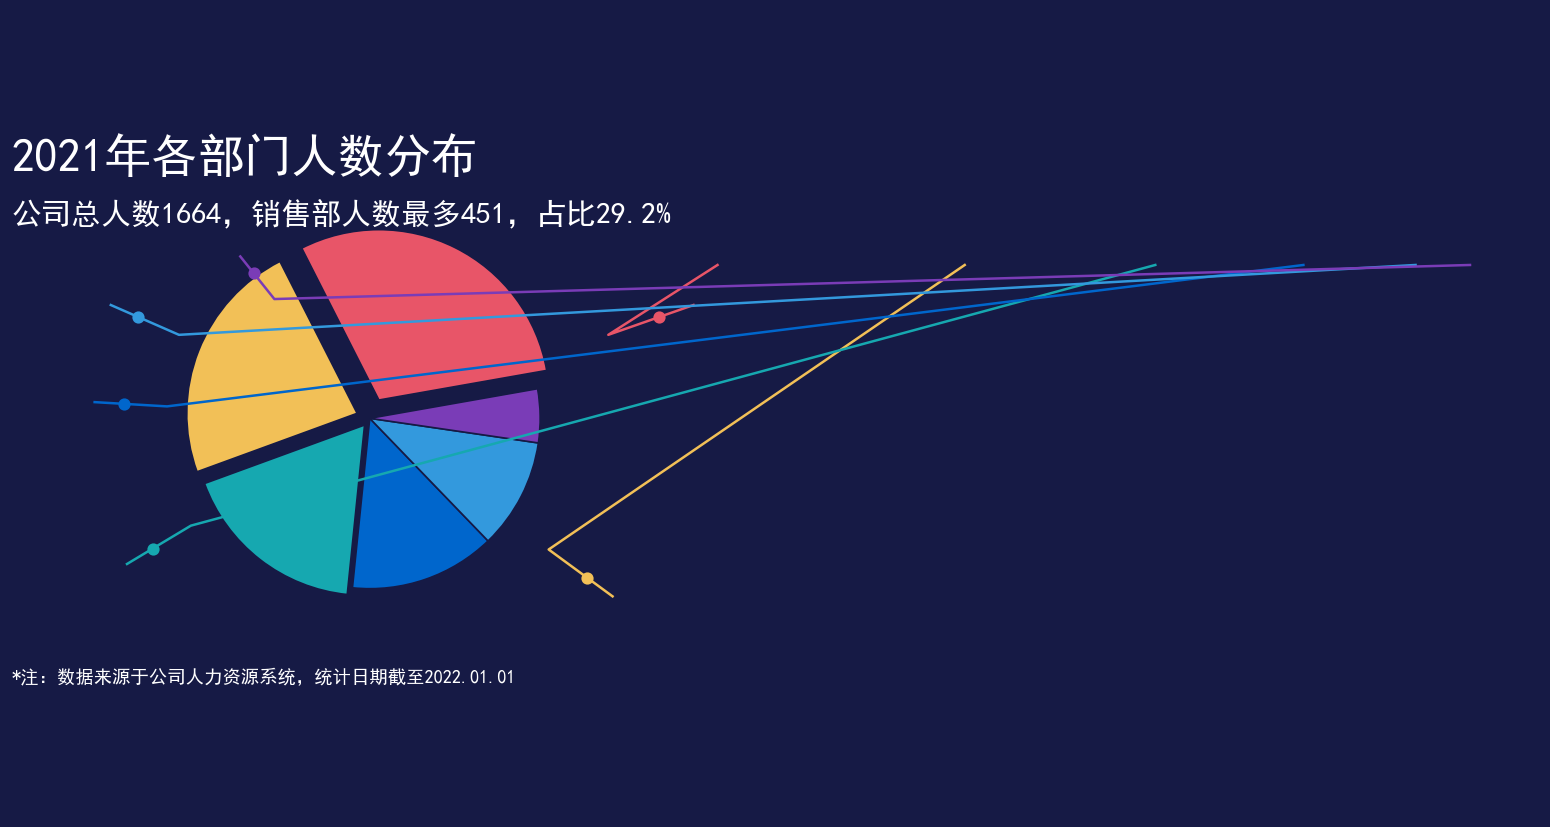

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 中文兼容配置 消除字体警告 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 1. 准备部门人数占比数据 ----------------------
departments = ["销售部", "采购部", "工程部", "财务部", "行政部", "人力部"]
percents = [29.2, 22.7, 17.5, 13.6, 10.3, 5.0]
colors = ['#e85568', '#f2c057', '#16a8b0', '#0066cc', '#3399dd', '#7a3cb7']
# 让占比最高的销售部和采购部轻微向外偏移
explode = [0.12, 0.08, 0.05, 0, 0, 0]

# ---------------------- 2. 画布与背景风格设置 ----------------------
plt.figure(figsize=(13, 7), dpi=120)
plt.gcf().set_facecolor('#161a45')
ax = plt.gca()
ax.set_facecolor('#161a45')

# ---------------------- 3. 绘制带偏移的半开口饼图 ----------------------
wedges, _ = ax.pie(
    percents,
    explode=explode,
    colors=colors,
    wedgeprops=dict(edgecolor='#161a45', linewidth=1),
    startangle=10
)

# ---------------------- 4. 绘制折线圆点引线标注 ----------------------
annot_pos = [
    (2.0, 0.7, '#e85568'),
    (1.5, -1.1, '#f2c057'),
    (-1.5, -0.9, '#16a8b0'),
    (-1.7, 0.1, '#0066cc'),
    (-1.6, 0.7, '#3399dd'),
    (-0.8, 1.0, '#7a3cb7')
]
for idx, (wedge, (tx, ty, c)) in enumerate(zip(wedges, annot_pos)):
    # 圆点标记
    ax.scatter(tx*0.85, ty*0.85, color=c, s=40, zorder=5)
    # 折线引线
    ax.plot([wedge.theta2/180*np.pi, tx*0.7, tx*0.95], 
            [wedge.r*0.9, ty*0.7, ty*0.95], color=c, linewidth=1.5)

# ---------------------- 5. 标题与底部注释 ----------------------
plt.text(-2.1, 1.45, '2021年各部门人数分布', color='white', fontsize=28, fontweight='bold')
plt.text(-2.1, 1.15, '公司总人数1664，销售部人数最多451，占比29.2%', color='white', fontsize=18)
plt.text(-2.1, -1.55, '*注：数据来源于公司人力资源系统，统计日期截至2022.01.01', color='white', fontsize=11)

# 保证饼图为正圆形
ax.axis('equal')
plt.tight_layout()
plt.show()


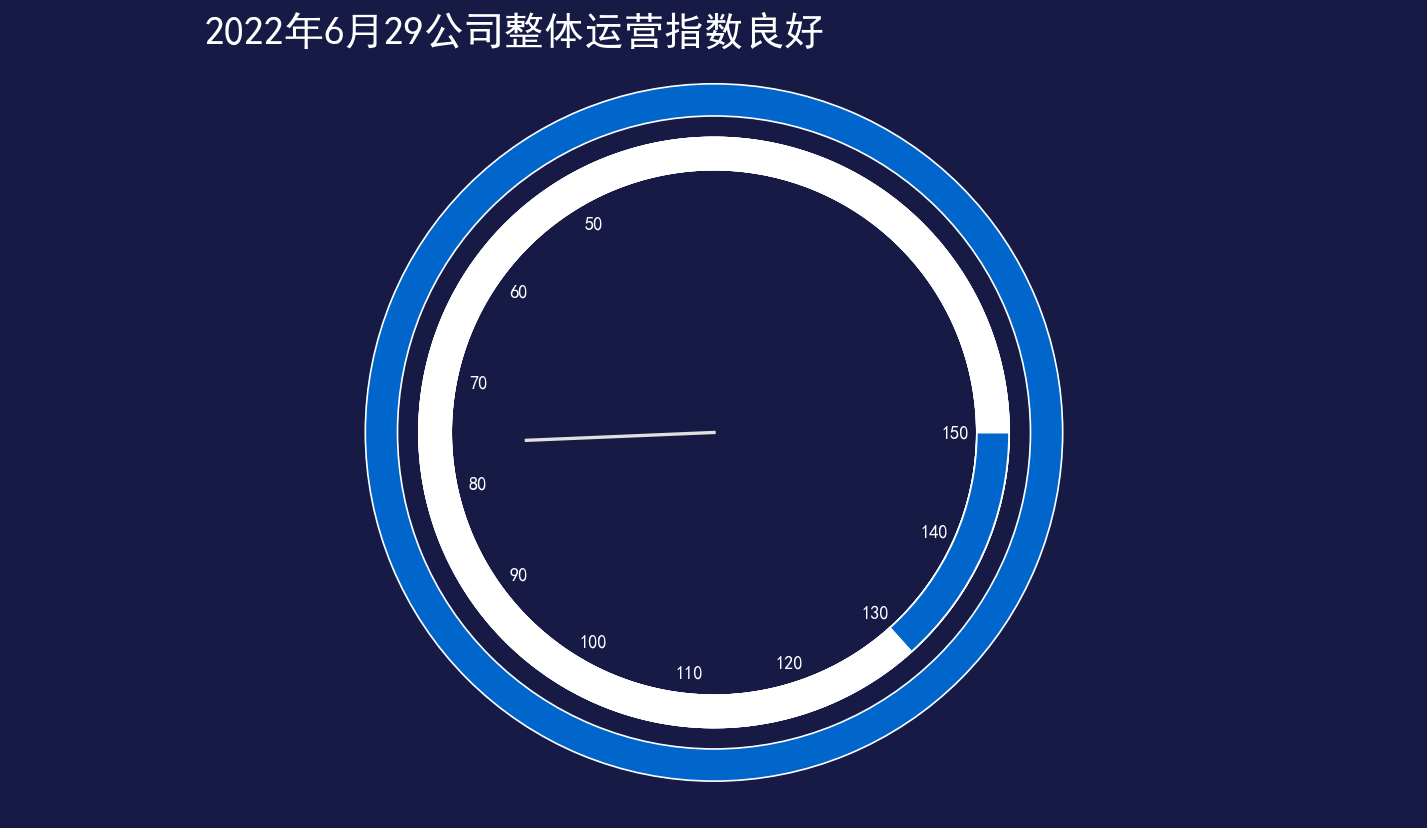

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 中文兼容配置 消除字体警告 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 1. 仪表盘基础参数 ----------------------
max_scale = 150
pointer_value = 76
# 分段颜色配置
color_segments = [
    {"range": (50, 80), "color": "#168899"},
    {"range": (80, 100), "color": "#f9c050"},
    {"range": (100, 130), "color": "#e84a68"},
    {"range": (130, 150), "color": "#0066cc"}
]
outer_ring_color = "#0066cc"

# ---------------------- 2. 画布与背景风格设置 ----------------------
plt.figure(figsize=(12, 7), dpi=120)
plt.gcf().set_facecolor('#161a45')
ax = plt.gca()
ax.set_facecolor('white')

# ---------------------- 3. 绘制外层蓝色全环 ----------------------
ax.pie(
    [100],
    colors=[outer_ring_color],
    radius=1.3,
    wedgeprops=dict(width=0.12, edgecolor='white', linewidth=1),
    startangle=0
)

# ---------------------- 4. 绘制内层分段彩色刻度环 ----------------------
for seg in color_segments:
    start_angle = (seg["range"][0] / max_scale) * 360
    seg_angle = ((seg["range"][1] - seg["range"][0]) / max_scale) * 360
    ax.pie(
        [seg_angle, 360 - seg_angle],
        colors=[seg["color"], 'white'],
        radius=1.1,
        wedgeprops=dict(width=0.12, edgecolor='white', linewidth=1),
        startangle=start_angle
    )

# ---------------------- 5. 绘制刻度数字标注 ----------------------
scale_values = [50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
for val in scale_values:
    angle = (val / max_scale) * 2 * np.pi
    x = 0.9 * np.cos(angle)
    y = 0.9 * np.sin(angle)
    ax.text(x, y, str(val), ha='center', va='center', color='white', fontsize=11)

# ---------------------- 6. 绘制白色指针 ----------------------
pointer_angle = (pointer_value / max_scale) * 2 * np.pi
ax.plot([0, 0.7 * np.cos(pointer_angle)], [0, 0.7 * np.sin(pointer_angle)], 
        color='#e0e0e0', linewidth=2, zorder=5)

# ---------------------- 7. 标题设置 ----------------------
plt.text(-1.9, 1.45, '2022年6月29公司整体运营指数良好', color='white', fontsize=24, fontweight='bold')

# 隐藏坐标轴，保证图形为正圆形
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.axis('equal')
plt.tight_layout()
plt.show()


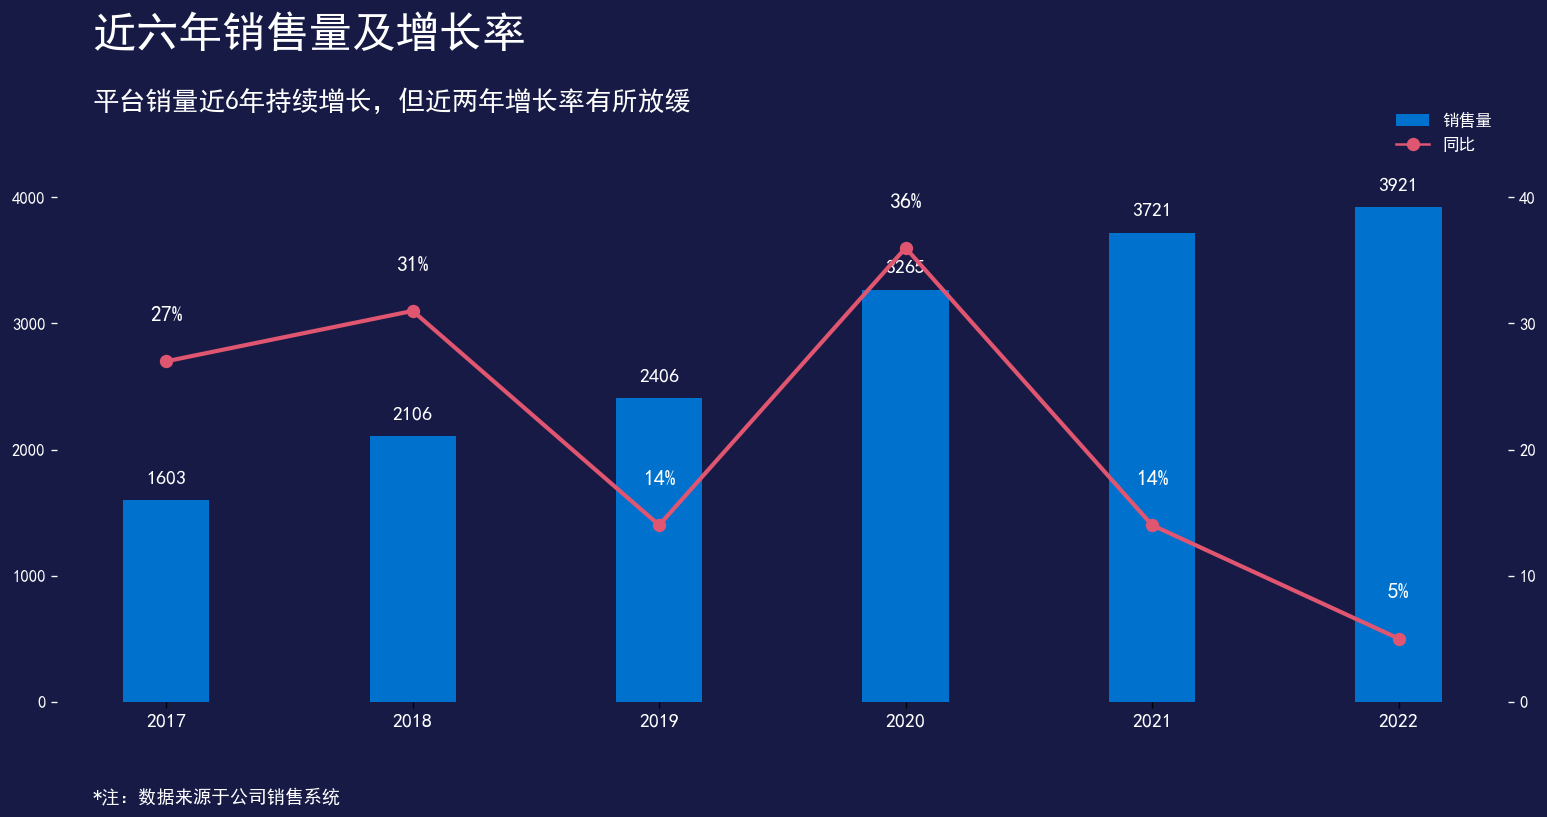

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 中文兼容配置 消除字体警告 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 1. 准备近6年销售数据 ----------------------
years = ["2017", "2018", "2019", "2020", "2021", "2022"]
sales = [1603, 2106, 2406, 3265, 3721, 3921]
growth_rates = [27, 31, 14, 36, 14, 5]
x = np.arange(len(years))
bar_color = '#0072ce'
line_color = '#e05570'

# ---------------------- 2. 画布与背景风格设置 ----------------------
fig, ax1 = plt.subplots(figsize=(13, 7), dpi=120)
fig.set_facecolor('#161a45')
ax1.set_facecolor('#161a45')

# ---------------------- 3. 绘制蓝色销量柱状图 ----------------------
bars = ax1.bar(x, sales, width=0.35, color=bar_color, zorder=2)
# 在柱子顶部标注销量数值
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 120,
             f'{int(height)}', ha='center', va='bottom', color='white', fontsize=12)

# ---------------------- 4. 配置柱状图坐标轴 ----------------------
ax1.set_xticks(x)
ax1.set_xticklabels(years, color='white', fontsize=12)
ax1.tick_params(axis='y', colors='white')
ax1.set_ylim(0, 4800)
# 隐藏多余边框
for spine in ax1.spines.values():
    spine.set_visible(False)

# ---------------------- 5. 绘制红色同比增长率折线图 ----------------------
ax2 = ax1.twinx()
ax2.plot(x, growth_rates, color=line_color, marker='o', markersize=7, linewidth=2.5, zorder=3)
# 在折线点上方标注增长率百分比
for idx, rate in enumerate(growth_rates):
    ax2.text(x[idx], rate + 3, f'{rate}%', ha='center', va='bottom', color='white', fontsize=13)

# ---------------------- 6. 配置折线图坐标轴 ----------------------
ax2.set_ylim(0, 48)
ax2.tick_params(axis='y', colors='white')
for spine in ax2.spines.values():
    spine.set_visible(False)

# ---------------------- 7. 标题、图例与底部注释 ----------------------
plt.text(-0.3, 52, '近六年销售量及增长率', color='white', fontsize=26, fontweight='bold')
plt.text(-0.3, 47, '平台销量近6年持续增长，但近两年增长率有所放缓', color='white', fontsize=16)
# 手动添加图例
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor=bar_color, label='销售量'),
    Line2D([0], [0], color=line_color, marker='o', linestyle='-', markersize=7, label='同比')
]
ax1.legend(handles=legend_elements, loc="upper right", frameon=False, labelcolor='white')

plt.text(-0.3, -8, '*注：数据来源于公司销售系统', color='white', fontsize=11)

plt.tight_layout()
plt.show()


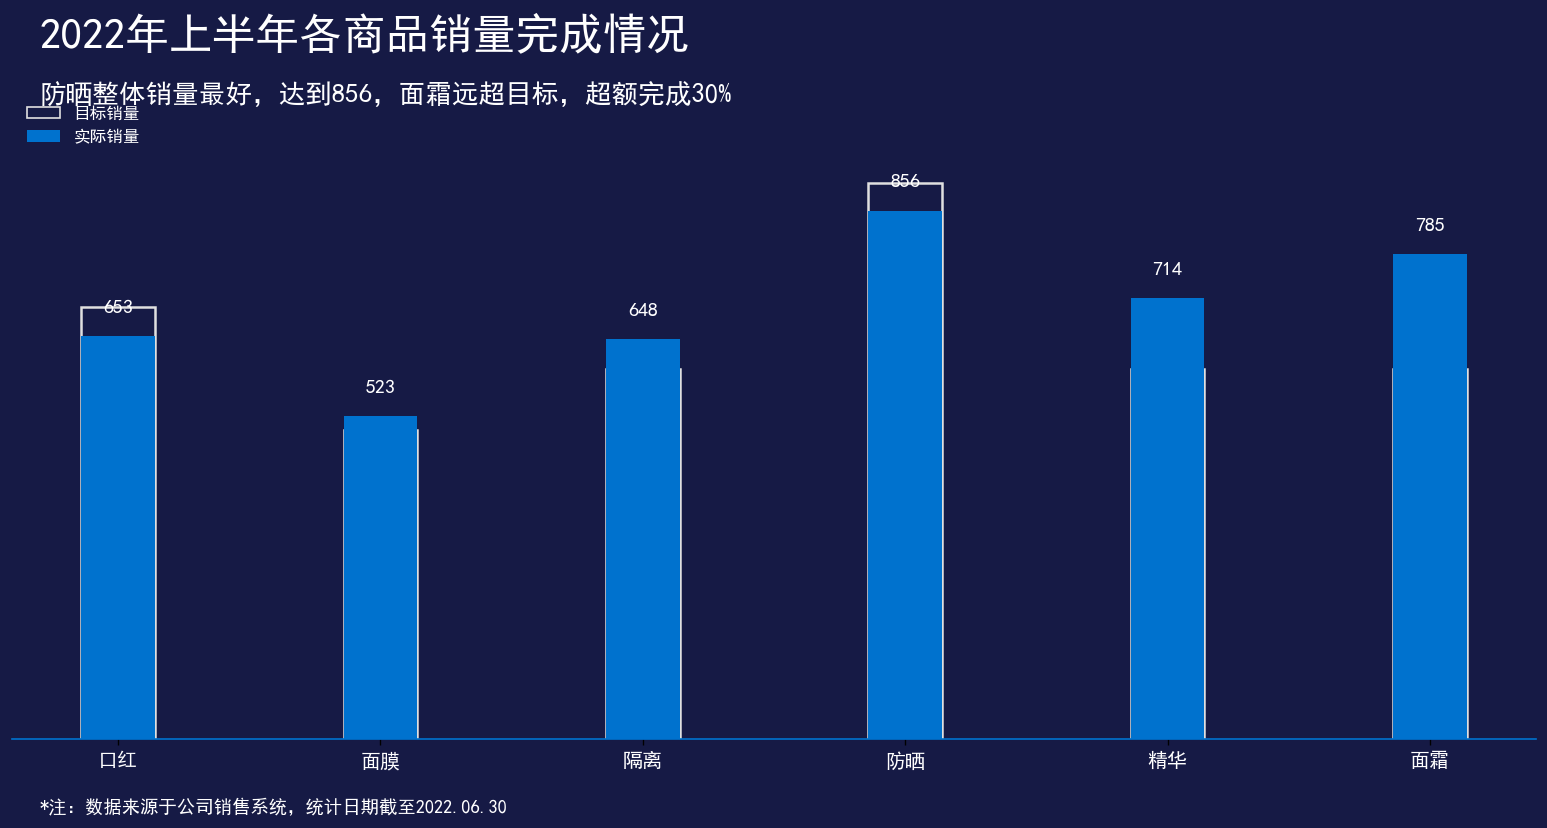

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 中文兼容配置 消除字体警告 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 1. 准备商品销量数据 ----------------------
products = ["口红", "面膜", "隔离", "防晒", "精华", "面霜"]
actual_sales = [653, 523, 648, 856, 714, 785]
target_sales = [700, 500, 600, 900, 600, 600]
x = np.arange(len(products))
bar_width = 0.28
actual_color = '#0072ce'
target_edge_color = '#e0e0e0'

# ---------------------- 2. 画布与背景风格设置 ----------------------
fig, ax = plt.subplots(figsize=(13, 7), dpi=120)
fig.set_facecolor('#161a45')
ax.set_facecolor('#161a45')

# ---------------------- 3. 绘制白色空心目标销量柱形 ----------------------
target_bars = ax.bar(x, target_sales, width=bar_width, 
                     facecolor='none', edgecolor=target_edge_color, linewidth=1.5, zorder=1)
# ---------------------- 4. 绘制蓝色实际销量柱形 ----------------------
actual_bars = ax.bar(x, actual_sales, width=bar_width, 
                     color=actual_color, zorder=2)

# ---------------------- 5. 在柱顶标注实际销量数值 ----------------------
for bar in actual_bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 35,
            f'{int(height)}', ha='center', va='bottom', color='white', fontsize=12)

# ---------------------- 6. 配置坐标轴 ----------------------
ax.set_xticks(x)
ax.set_xticklabels(products, color='white', fontsize=12)
ax.tick_params(axis='y', left=False, labelleft=False)
ax.set_ylim(0, 1050)
# 仅保留底部蓝色基准线
ax.spines['bottom'].set_color('#0072ce')
ax.spines['bottom'].set_linewidth(1)
# 隐藏其余边框
for spine in ['top', 'left', 'right']:
    spine_obj = ax.spines[spine]
    spine_obj.set_visible(False)

# ---------------------- 7. 标题、图例与底部注释 ----------------------
plt.text(-0.3, 1120, '2022年上半年各商品销量完成情况', color='white', fontsize=26, fontweight='bold')
plt.text(-0.3, 1030, '防晒整体销量最好，达到856，面霜远超目标，超额完成30%', color='white', fontsize=16)
# 手动添加图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='none', edgecolor=target_edge_color, label='目标销量'),
    Patch(facecolor=actual_color, label='实际销量')
]
ax.legend(handles=legend_elements, loc="upper left", frameon=False, labelcolor='white')

plt.text(-0.3, -120, '*注：数据来源于公司销售系统，统计日期截至2022.06.30', color='white', fontsize=11)

plt.tight_layout()
plt.show()


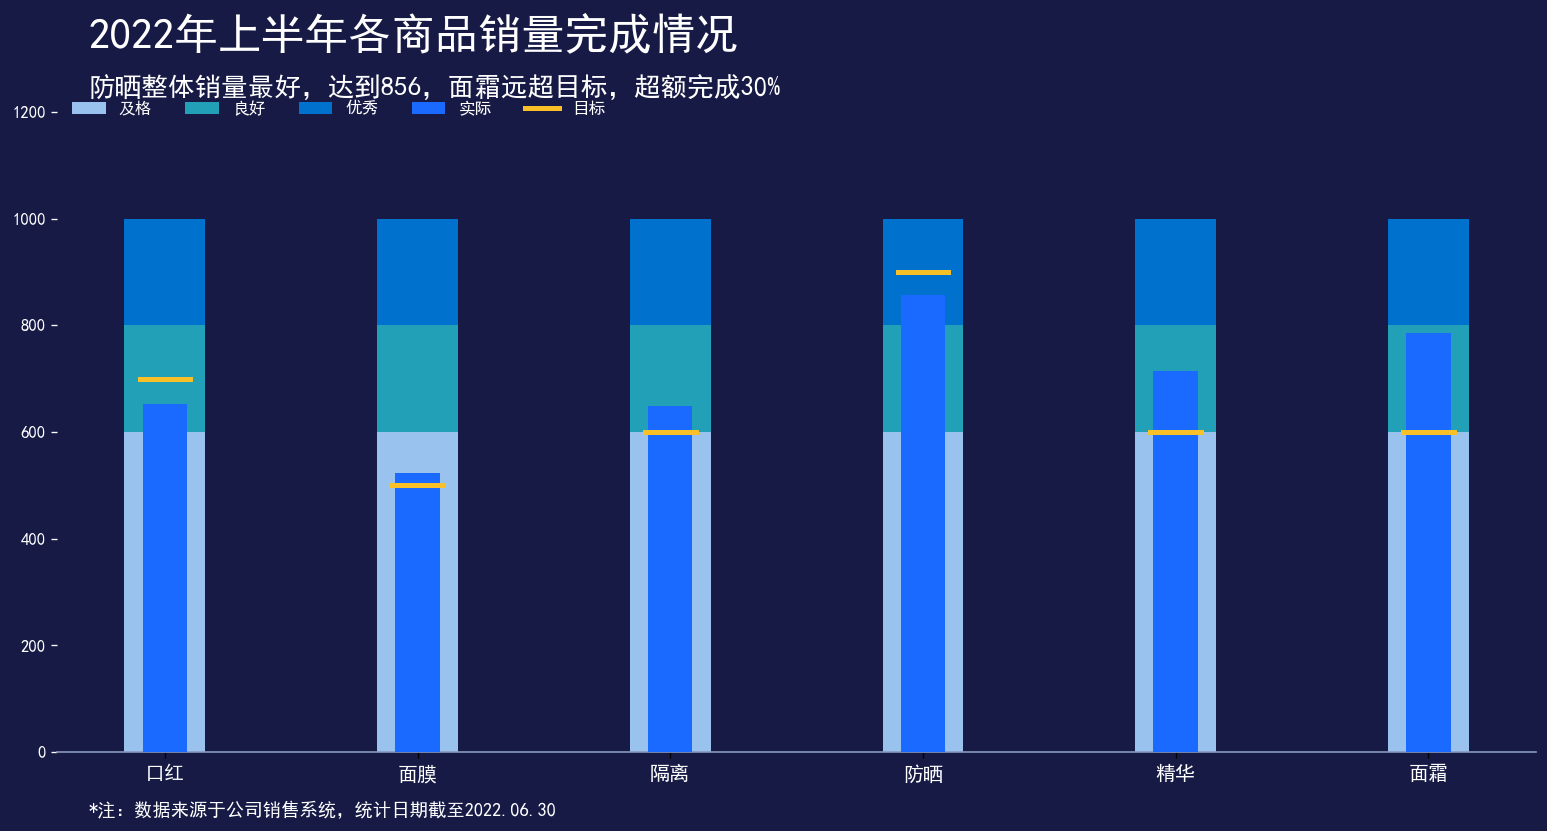

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 中文兼容配置 消除字体警告 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 1. 准备各维度销量数据 ----------------------
products = ["口红", "面膜", "隔离", "防晒", "精华", "面霜"]
actual_sales = [653, 523, 648, 856, 714, 785]
target_sales = [700, 500, 600, 900, 600, 600]
pass_line = [600, 600, 600, 600, 600, 600]
good_line = [200, 200, 200, 200, 200, 200]
excellent_line = [200, 200, 200, 200, 200, 200]
x = np.arange(len(products))
bar_width = 0.32

# 各层配色
color_pass = '#99c2ee'
color_good = '#22a0b8'
color_excellent = '#0072ce'
color_actual = '#1a6aff'
color_target = '#f9c028'

# ---------------------- 2. 画布与背景风格设置 ----------------------
fig, ax = plt.subplots(figsize=(13, 7), dpi=120)
fig.set_facecolor('#161a45')
ax.set_facecolor('#161a45')

# ---------------------- 3. 从底层到顶层依次绘制分层基准柱 ----------------------
# 底层及格层
ax.bar(x, pass_line, width=bar_width, color=color_pass, zorder=1)
# 中间良好层
ax.bar(x, good_line, bottom=pass_line, width=bar_width, color=color_good, zorder=2)
# 顶层优秀层
ax.bar(x, excellent_line, bottom=np.array(pass_line)+np.array(good_line), width=bar_width, color=color_excellent, zorder=3)
# 蓝色实际销量柱
ax.bar(x, actual_sales, width=bar_width*0.55, color=color_actual, zorder=4)
# 黄色短横线目标销量标记
for idx, target_val in enumerate(target_sales):
    ax.plot([x[idx]-0.1, x[idx]+0.1], [target_val, target_val], color=color_target, linewidth=3, zorder=5)

# ---------------------- 4. 配置坐标轴 ----------------------
ax.set_xticks(x)
ax.set_xticklabels(products, color='white', fontsize=12)
ax.tick_params(axis='y', colors='white')
ax.set_ylim(0, 1250)
# 仅保留底部浅灰色基准线
ax.spines['bottom'].set_color('#8899bb')
ax.spines['bottom'].set_linewidth(1)
# 隐藏其余边框
for spine in ['top', 'left', 'right']:
    spine_obj = ax.spines[spine]
    spine_obj.set_visible(False)

# ---------------------- 5. 标题、图例与底部注释 ----------------------
plt.text(-0.3, 1320, '2022年上半年各商品销量完成情况', color='white', fontsize=26, fontweight='bold')
plt.text(-0.3, 1230, '防晒整体销量最好，达到856，面霜远超目标，超额完成30%', color='white', fontsize=16)
# 手动添加图例
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor=color_pass, label='及格'),
    Patch(facecolor=color_good, label='良好'),
    Patch(facecolor=color_excellent, label='优秀'),
    Patch(facecolor=color_actual, label='实际'),
    Line2D([0], [0], color=color_target, linewidth=3, label='目标')
]
ax.legend(handles=legend_elements, loc="upper left", frameon=False, labelcolor='white', ncol=5)

plt.text(-0.3, -120, '*注：数据来源于公司销售系统，统计日期截至2022.06.30', color='white', fontsize=11)

plt.tight_layout()
plt.show()


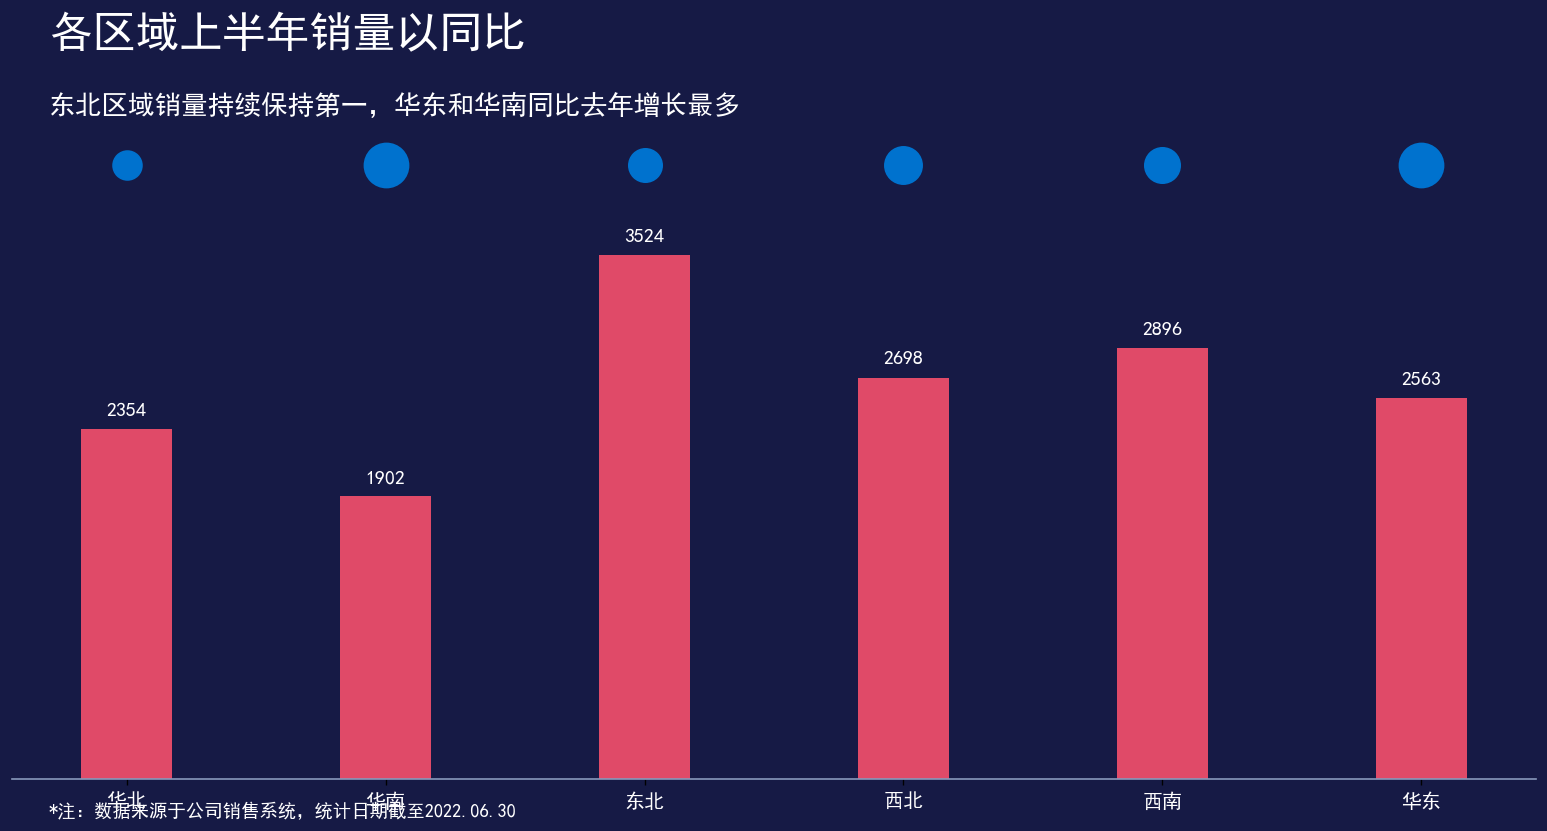

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 中文兼容配置 消除字体警告 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 1. 准备区域销量数据 ----------------------
regions = ["华北", "华南", "东北", "西北", "西南", "华东"]
sales = [2354, 1902, 3524, 2698, 2896, 2563]
growth_rates = [12, 25, 16, 21, 18, 25]
x = np.arange(len(regions))
bar_width = 0.35
bar_color = '#e04a68'
circle_color = '#0072ce'

# ---------------------- 2. 画布与背景风格设置 ----------------------
fig, ax = plt.subplots(figsize=(13, 7), dpi=120)
fig.set_facecolor('#161a45')
ax.set_facecolor('#161a45')

# ---------------------- 3. 绘制红色销量柱形 ----------------------
bars = ax.bar(x, sales, width=bar_width, color=bar_color, zorder=2)
# 在柱子顶部标注销量数值
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 80,
            f'{int(height)}', ha='center', va='bottom', color='white', fontsize=12)

# ---------------------- 4. 绘制顶部蓝色同比圆点+百分比标注 ----------------------
circle_sizes = [300, 700, 400, 500, 450, 700]
for idx, (rate, size) in enumerate(zip(growth_rates, circle_sizes)):
    ax.scatter(x[idx], max(sales)+600, s=size, color=circle_color, zorder=5)
    ax.text(x[idx], max(sales)+600, f'{rate}%', ha='center', va='center', color='white', fontsize=12)

# ---------------------- 5. 配置坐标轴 ----------------------
ax.set_xticks(x)
ax.set_xticklabels(regions, color='white', fontsize=12)
ax.tick_params(axis='y', left=False, labelleft=False)
ax.set_ylim(0, max(sales)+1000)
# 仅保留底部浅灰色基准线
ax.spines['bottom'].set_color('#8899bb')
ax.spines['bottom'].set_linewidth(1)
# 隐藏其余边框
for spine in ['top', 'left', 'right']:
    spine_obj = ax.spines[spine]
    spine_obj.set_visible(False)

# ---------------------- 6. 标题与底部注释 ----------------------
plt.text(-0.3, max(sales)+1400, '各区域上半年销量以同比', color='white', fontsize=26, fontweight='bold')
plt.text(-0.3, max(sales)+950, '东北区域销量持续保持第一，华东和华南同比去年增长最多', color='white', fontsize=16)

plt.text(-0.3, -250, '*注：数据来源于公司销售系统，统计日期截至2022.06.30', color='white', fontsize=11)

plt.tight_layout()
plt.show()


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 中文兼容配置 消除字体警告 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 1. 准备区域销量数据 ----------------------
regions = ["华北", "华南", "东北", "西北", "西南", "华东"]
sales_2022 = [2354, 1902, 3524, 2698, 2896, 2563]
sales_2021 = [2021, 1563, 3213, 2531, 2631, 2361]
growth_rates = [16, 22, 10, 7, 10, 9]
x = np.arange(len(regions))
bar_width = 0.22
color_2022 = '#0072ce'
color_2021 = '#e04a68'
line_color = '#f9c008'

# ---------------------- 2. 画布与背景风格设置 ----------------------
fig, ax1 = plt.subplots(figsize=(13, 8), dpi=120)
fig.set_facecolor('#161a45')
ax1.set_facecolor('#161a45')

# ---------------------- 3. 绘制2022和2021双年份对比柱形 ----------------------
bars_2022 = ax1.bar(x - bar_width/2, sales_2022, width=bar_width, color=color_2022, zorder=2)
bars_2021 = ax1.bar(x + bar_width/2, sales_2021, width=bar_width, color=color_2021, zorder=2)

# 在柱子顶部标注对应年份销量数值
for bar in bars_2022:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 70,
             f'{int(height)}', ha='center', va='bottom', color='white', fontsize=12)
for bar in bars_2021:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 70,
             f'{int(height)}', ha='center', va='bottom', color='white', fontsize=12)

# ---------------------- 4. 绘制顶部黄色同比增长率折线 ----------------------
ax2 = ax1.twinx()
ax2.plot(x, growth_rates, color=line_color, marker='o', markersize=7, linewidth=2.5, zorder=5)
# 在折线点上方标注增长率百分比
for idx, rate in enumerate(growth_rates):
    ax2.text(x[idx], rate + 2.2, f'{rate}%', ha='center', va='bottom', color='white', fontsize=12)

# ---------------------- 5. 配置坐标轴 ----------------------
ax1.set_xticks(x)
ax1.set_xticklabels(regions, color='white', fontsize=12)
ax1.tick_params(axis='y', left=False, labelleft=False)
ax1.set_ylim(0, 4200)
ax2.set_ylim(0, 32)
ax2.tick_params(axis='y', right=False, labelright=False)
# 仅保留底部浅灰色基准线
ax1.spines['bottom'].set_color('#8899bb')
ax1.spines['bottom'].set_linewidth(1)
# 隐藏其余边框
for spine in ['top', 'left', 'right']:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

# ---------------------- 6. 标题、图例与底部注释 ----------------------
plt.text(-0.25, 4400, '上半年各月商品销量同比去年情况', color='white', fontsize=26, fontweight='bold')
plt.text(-0.25, 4050, '2022年相比于2021年销量都有提升，半年整体提升17%', color='white', fontsize=16)
# 手动添加带边框样式的图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_2022, edgecolor='#3399dd', label='2022'),
    Patch(facecolor=color_2021, edgecolor='#ff7788', label='2021')
]
ax1.legend(handles=legend_elements, loc="lower right", frameon=True, 
           facecolor='#161a45', edgecolor='white', labelcolor='white')

plt.text(-0.25, -280, '*注：数据来源于公司销售系统，统计日期截至2022.06.30', color='white', fontsize=11)

# 手动设置边距，完全替代tight_layout避免警告
plt.subplots_adjust(left=0.12, right=0.95, top=0.82, bottom=0.18)
plt.show()


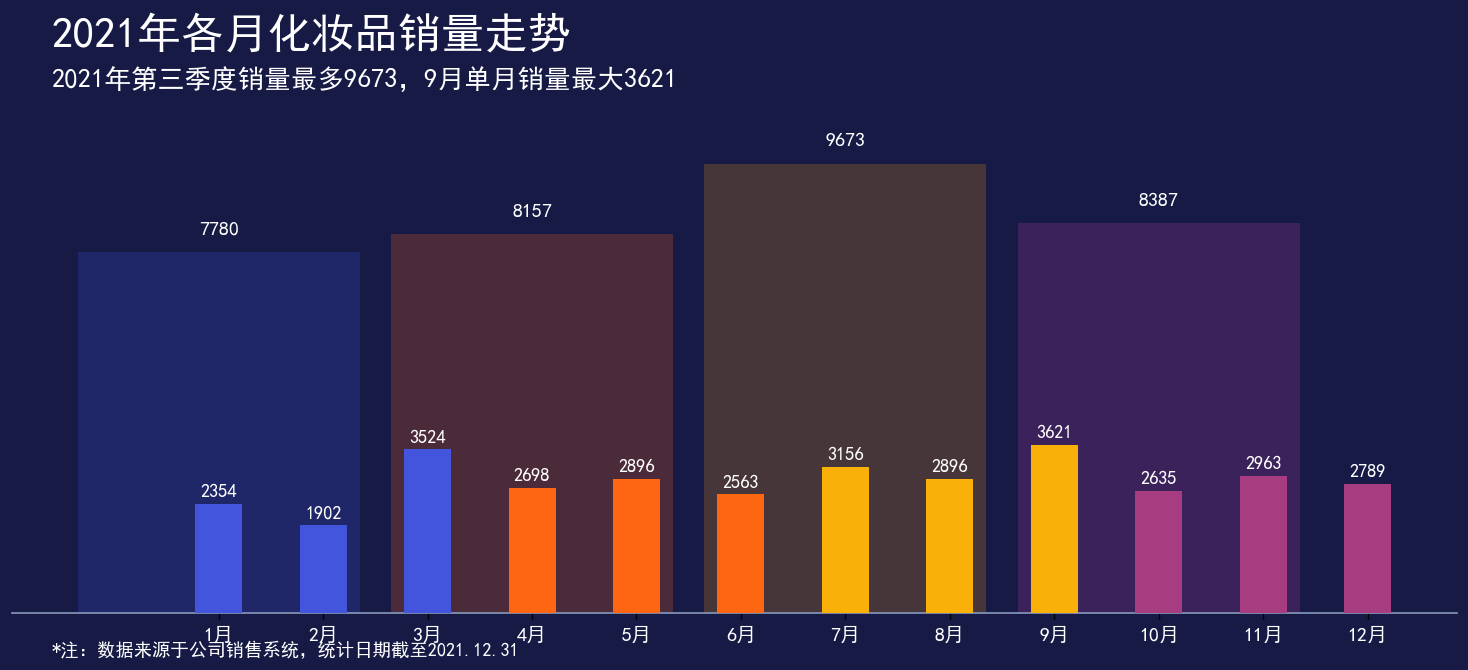

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 中文兼容配置 消除字体警告 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 1. 准备季度和月度销量数据 ----------------------
quarter_names = ["Q1", "Q2", "Q3", "Q4"]
quarter_sales = [7780, 8157, 9673, 8387]
quarter_colors = ['#222a70', '#552e38', '#503c38', '#422460']
month_names = ["1月", "2月", "3月", "4月", "5月", "6月", "7月", "8月", "9月", "10月", "11月", "12月"]
month_sales = [2354, 1902, 3524, 2698, 2896, 2563, 3156, 2896, 3621, 2635, 2963, 2789]
month_colors = ['#4455dd', '#4455dd', '#4455dd', 
                '#ff6611', '#ff6611', '#ff6611',
                '#f9b008', '#f9b008', '#f9b008',
                '#a83c80', '#a83c80', '#a83c80']

# ---------------------- 2. 画布与背景风格设置 ----------------------
fig, ax = plt.subplots(figsize=(14, 7), dpi=120)
fig.set_facecolor('#161a45')
ax.set_facecolor('#161a45')

# ---------------------- 3. 绘制季度大背景柱形 ----------------------
quarter_x = [1, 4, 7, 10]
quarter_bar_width = 2.7
for idx, (x_pos, q_sale, q_color) in enumerate(zip(quarter_x, quarter_sales, quarter_colors)):
    q_bar = ax.bar(x_pos, q_sale, width=quarter_bar_width, color=q_color, alpha=0.85, zorder=1)
    ax.text(x_pos, q_sale + 350, f'{q_sale}', ha='center', va='bottom', color='white', fontsize=12)

# ---------------------- 4. 绘制月度小柱形 ----------------------
month_x = np.arange(1, 13)
month_bar_width = 0.45
m_bars = ax.bar(month_x, month_sales, width=month_bar_width, color=month_colors, zorder=3)
# 在月度柱顶标注销量数值
for bar in m_bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 120,
            f'{int(height)}', ha='center', va='bottom', color='white', fontsize=11)

# ---------------------- 5. 配置坐标轴 ----------------------
ax.set_xticks(month_x)
ax.set_xticklabels(month_names, color='white', fontsize=12)
ax.tick_params(axis='y', left=False, labelleft=False)
ax.set_ylim(0, 11200)
# 仅保留底部浅灰色基准线
ax.spines['bottom'].set_color('#8899bb')
ax.spines['bottom'].set_linewidth(1)
# 隐藏其余边框
for spine in ['top', 'left', 'right']:
    ax.spines[spine].set_visible(False)

# ---------------------- 6. 标题与底部注释 ----------------------
plt.text(-0.6, 12200, '2021年各月化妆品销量走势', color='white', fontsize=26, fontweight='bold')
plt.text(-0.6, 11300, '2021年第三季度销量最多9673，9月单月销量最大3621', color='white', fontsize=16)

plt.text(-0.6, -900, '*注：数据来源于公司销售系统，统计日期截至2021.12.31', color='white', fontsize=11)

# 手动设置边距避免布局警告
plt.subplots_adjust(left=0.1, right=0.96, top=0.8, bottom=0.18)
plt.show()


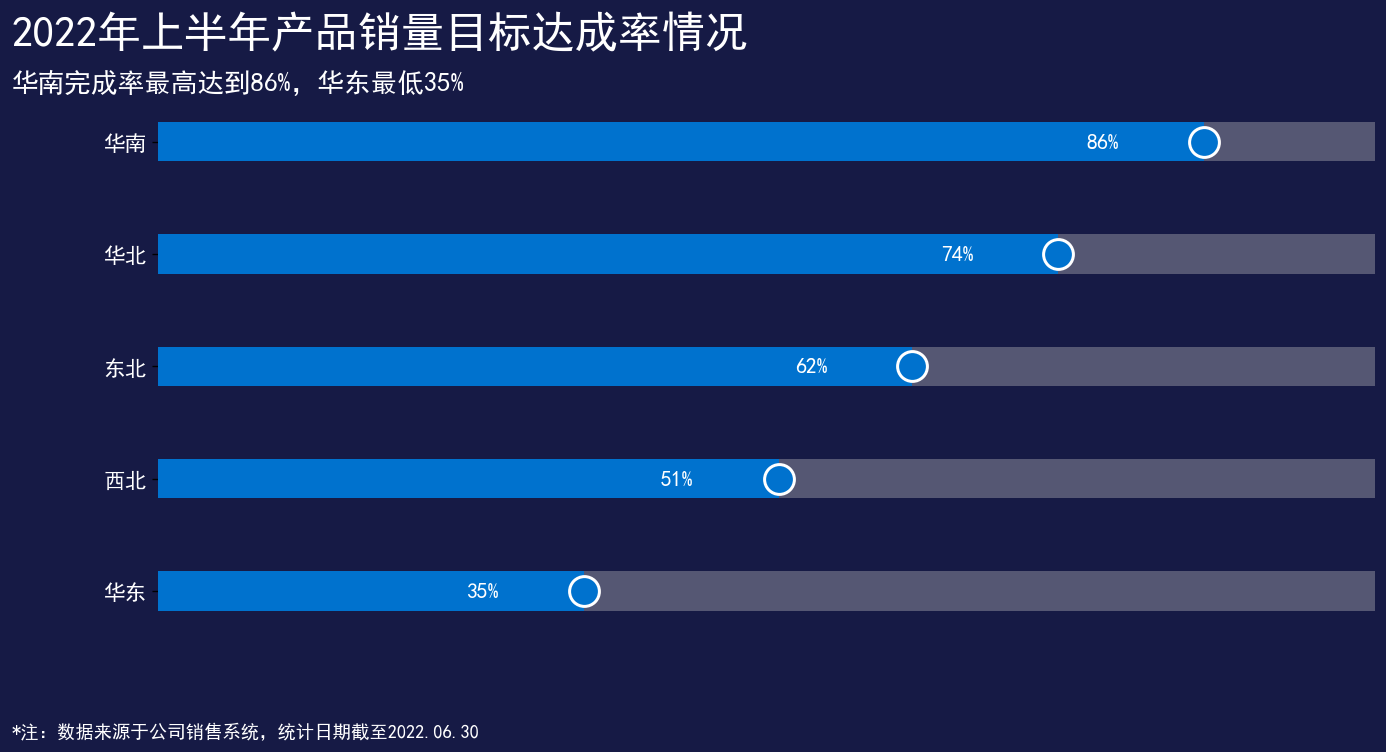

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 中文兼容配置 消除字体警告 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 1. 准备区域达成率数据 ----------------------
regions = ["华南", "华北", "东北", "西北", "华东"]
completion_rates = [86, 74, 62, 51, 35]
bar_bg_color = '#707288'
bar_fill_color = '#0072ce'

# ---------------------- 2. 画布与背景风格设置 ----------------------
fig, ax = plt.subplots(figsize=(13, 7), dpi=120)
fig.set_facecolor('#161a45')
ax.set_facecolor('#161a45')

# ---------------------- 3. 绘制横向进度条 ----------------------
y_pos = np.arange(len(regions))
bar_height = 0.35
# 先绘制灰色背景全量进度条
ax.barh(y_pos, [100]*len(regions), height=bar_height, color=bar_bg_color, alpha=0.7, zorder=1)
# 再绘制蓝色已完成部分进度条
fill_bars = ax.barh(y_pos, completion_rates, height=bar_height, color=bar_fill_color, zorder=2)

# ---------------------- 4. 绘制进度末端蓝色圆点+白色边框+百分比标注 ----------------------
for idx, rate in enumerate(completion_rates):
    # 带白边的蓝色圆点
    ax.scatter(rate, y_pos[idx], s=320, color=bar_fill_color, edgecolor='white', linewidth=1.8, zorder=5)
    # 百分比文字标注
    ax.text(rate - 7, y_pos[idx], f'{rate}%', ha='right', va='center', color='white', fontsize=13)

# ---------------------- 5. 配置坐标轴 ----------------------
ax.set_yticks(y_pos)
ax.set_yticklabels(regions, color='white', fontsize=13)
ax.invert_yaxis()  # 让华南排在最顶部，和示例顺序一致
ax.tick_params(axis='x', bottom=False, labelbottom=False)
ax.set_xlim(0, 100)
# 隐藏所有边框
for spine in ax.spines.values():
    spine.set_visible(False)

# ---------------------- 6. 标题与底部注释 ----------------------
plt.text(-12, -0.85, '2022年上半年产品销量目标达成率情况', color='white', fontsize=26, fontweight='bold')
plt.text(-12, -0.45, '华南完成率最高达到86%，华东最低35%', color='white', fontsize=16)

plt.text(-12, 5.3, '*注：数据来源于公司销售系统，统计日期截至2022.06.30', color='white', fontsize=11)

# 手动设置边距避免布局警告
plt.subplots_adjust(left=0.18, right=0.96, top=0.82, bottom=0.18)
plt.show()


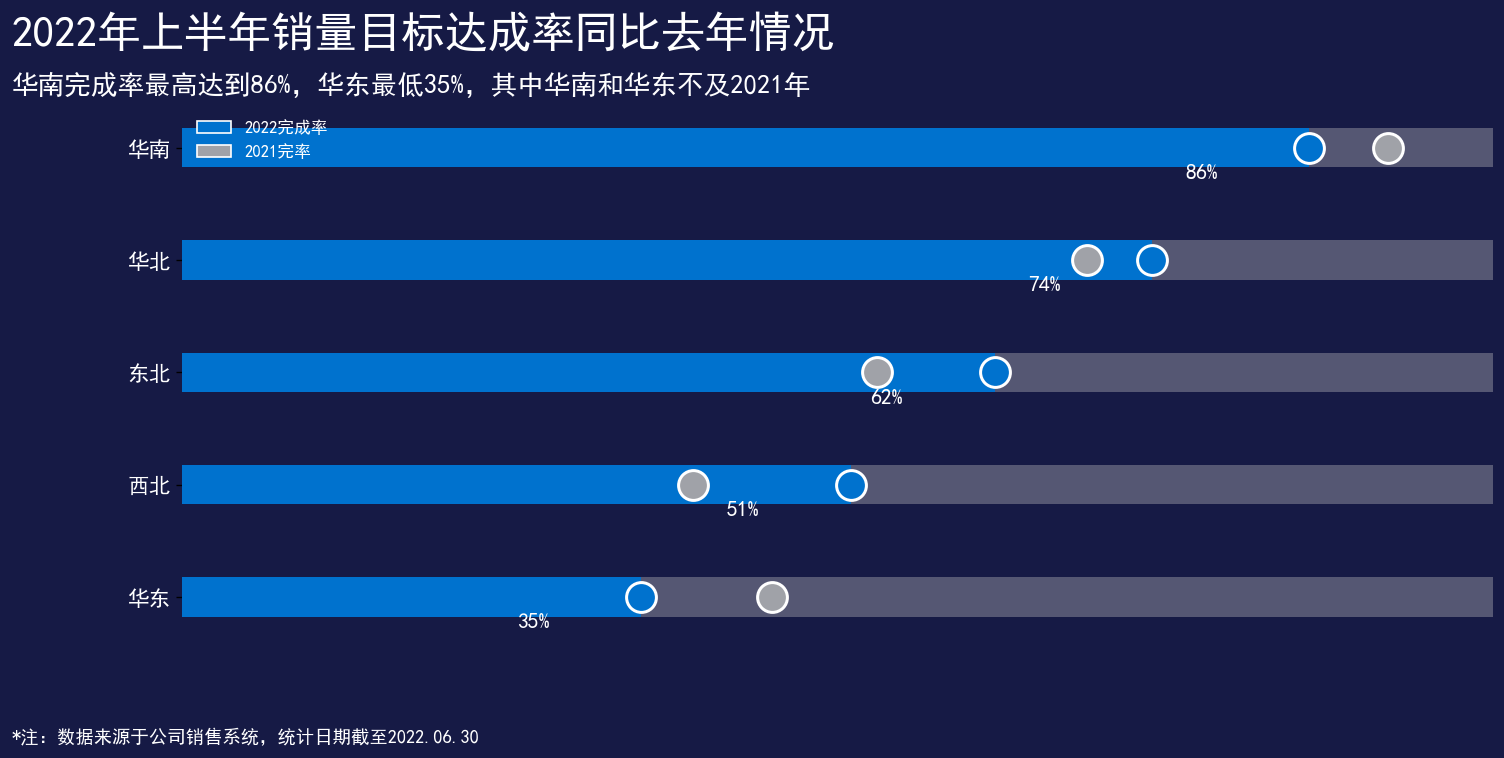

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 中文兼容配置 消除字体警告 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 1. 准备区域双年份达成率数据 ----------------------
regions = ["华南", "华北", "东北", "西北", "华东"]
rate_2022 = [86, 74, 62, 51, 35]
rate_2021 = [92, 69, 53, 39, 45]
bar_bg_color = '#707288'
bar_fill_color = '#0072ce'
dot_2022_color = '#0072ce'
dot_2021_color = '#a0a2a8'

# ---------------------- 2. 画布与背景风格设置 ----------------------
fig, ax = plt.subplots(figsize=(14, 7), dpi=120)
fig.set_facecolor('#161a45')
ax.set_facecolor('#161a45')

# ---------------------- 3. 绘制横向进度条 ----------------------
y_pos = np.arange(len(regions))
bar_height = 0.35
# 先绘制灰色背景全量进度条
ax.barh(y_pos, [100]*len(regions), height=bar_height, color=bar_bg_color, alpha=0.7, zorder=1)
# 再绘制蓝色2022已完成部分进度条
fill_bars = ax.barh(y_pos, rate_2022, height=bar_height, color=bar_fill_color, zorder=2)

# ---------------------- 4. 绘制双年份圆点标注 ----------------------
for idx, (r22, r21) in enumerate(zip(rate_2022, rate_2021)):
    # 2022蓝色带白边圆点
    ax.scatter(r22, y_pos[idx], s=320, color=dot_2022_color, edgecolor='white', linewidth=1.8, zorder=5)
    # 2021灰色带白边圆点
    ax.scatter(r21, y_pos[idx], s=320, color=dot_2021_color, edgecolor='white', linewidth=1.8, zorder=4)
    # 2022百分比文字标注
    ax.text(r22 - 7, y_pos[idx] + 0.22, f'{r22}%', ha='right', va='center', color='white', fontsize=13)

# ---------------------- 5. 配置坐标轴 ----------------------
ax.set_yticks(y_pos)
ax.set_yticklabels(regions, color='white', fontsize=13)
ax.invert_yaxis()  # 让华南排在最顶部，和示例顺序一致
ax.tick_params(axis='x', bottom=False, labelbottom=False)
ax.set_xlim(0, 100)
# 隐藏所有边框
for spine in ax.spines.values():
    spine.set_visible(False)

# ---------------------- 6. 标题、图例与底部注释 ----------------------
plt.text(-13, -0.9, '2022年上半年销量目标达成率同比去年情况', color='white', fontsize=26, fontweight='bold')
plt.text(-13, -0.48, '华南完成率最高达到86%，华东最低35%，其中华南和华东不及2021年', color='white', fontsize=16)
# 手动添加图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=dot_2022_color, edgecolor='white', label='2022完成率'),
    Patch(facecolor=dot_2021_color, edgecolor='white', label='2021完率')
]
ax.legend(handles=legend_elements, loc="upper left", frameon=False, labelcolor='white')

plt.text(-13, 5.3, '*注：数据来源于公司销售系统，统计日期截至2022.06.30', color='white', fontsize=11)

# 手动设置边距避免布局警告
plt.subplots_adjust(left=0.18, right=0.96, top=0.82, bottom=0.18)
plt.show()
